<a href="https://colab.research.google.com/github/Stamatics-NumberstoNeurons/assignment2-nupur-sehgal/blob/main/Assignment_2_N2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [2]:
class NANDPerceptron:
    def __init__(self):
        # mathematically determined weights and bias
        self.weights = np.array([-1, -1])
        self.bias = 1.5

    def predict(self, X):

        # weighted sum using vectorized operations
        z = np.dot(X, self.weights) + self.bias

        # step activation function
        return (z >= 0).astype(int)


# Example usage
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

nand = NANDPerceptron()
output = nand.predict(X)

print("Outputs:", output)

Outputs: [1 1 1 0]


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:**
A tiny weight change can cause chaos in a perceptron network because the perceptron uses a discontinuous step activation function, where small changes near the decision boundary can abruptly flip outputs from 0 to 1.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**
1. As c approaches infinity, a sigmoid neuron behaves exactly like a classical perceptron.
σ(z)=1/(1+exp(-z)) where z=wx+b.
Now when z>0, output is 1 and when z<0 output is 0. Same behaviour as a classic perceptron which is that of a step function.
2. However, we prefer sigmoid neurons because they are smooth and differentiable, enabling gradient descent and backpropagation, unlike perceptrons which use a non-differentiable hard threshold.


---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**
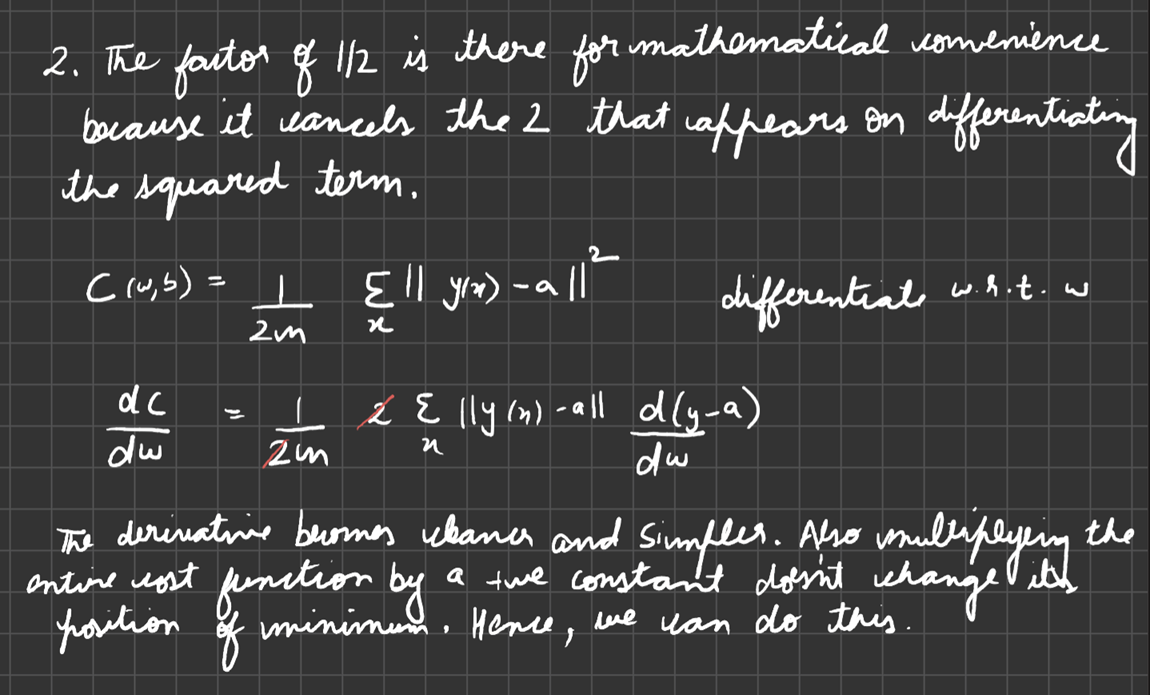

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**
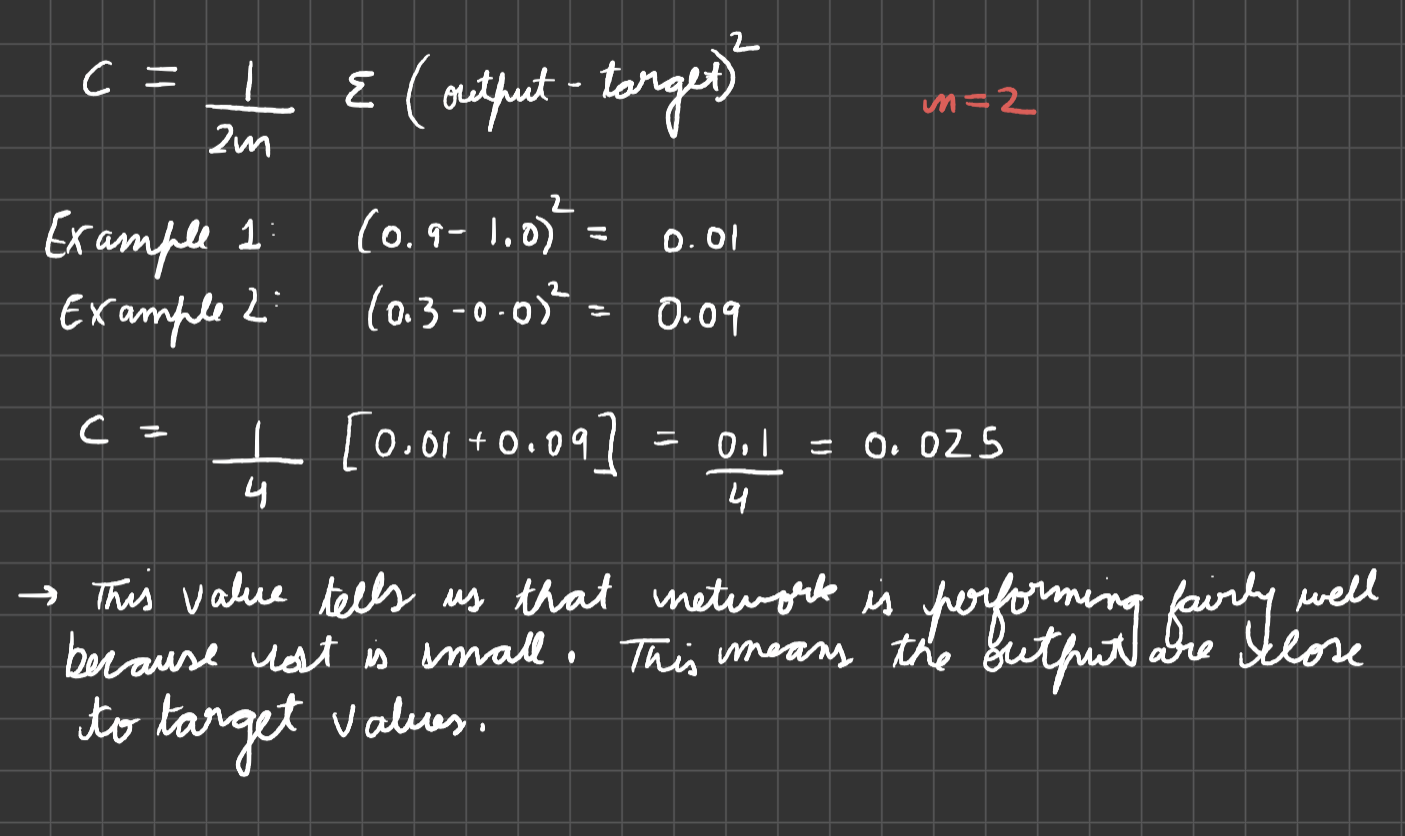.

In [3]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

n = len(outputs)

C_val = (1 / (2 * n)) * np.sum((outputs - targets) ** 2)

print(f'C = {C_val:0.3f}')

C = 0.025


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**
We use a cost function instead of directly maximizing classification accuracy because accuracy is a discrete, non-differentiable measure that does not show how small weight changes affect performance. Cost functions provide smooth, continuous feedback that can be differentiated and minimized using methods like gradient descent.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**
Gradient descent requires cost function to be differentiable. Here, absolute error function is not differentiable at y=a, thus making it difficult for optimization in compared to squared error.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**
When w=3 and b=1, the value of C will be minimum which will be 0. This is because adding two squared terms will always result in number greater than or equal to 0. Thus minimum value of C is 0.

### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**
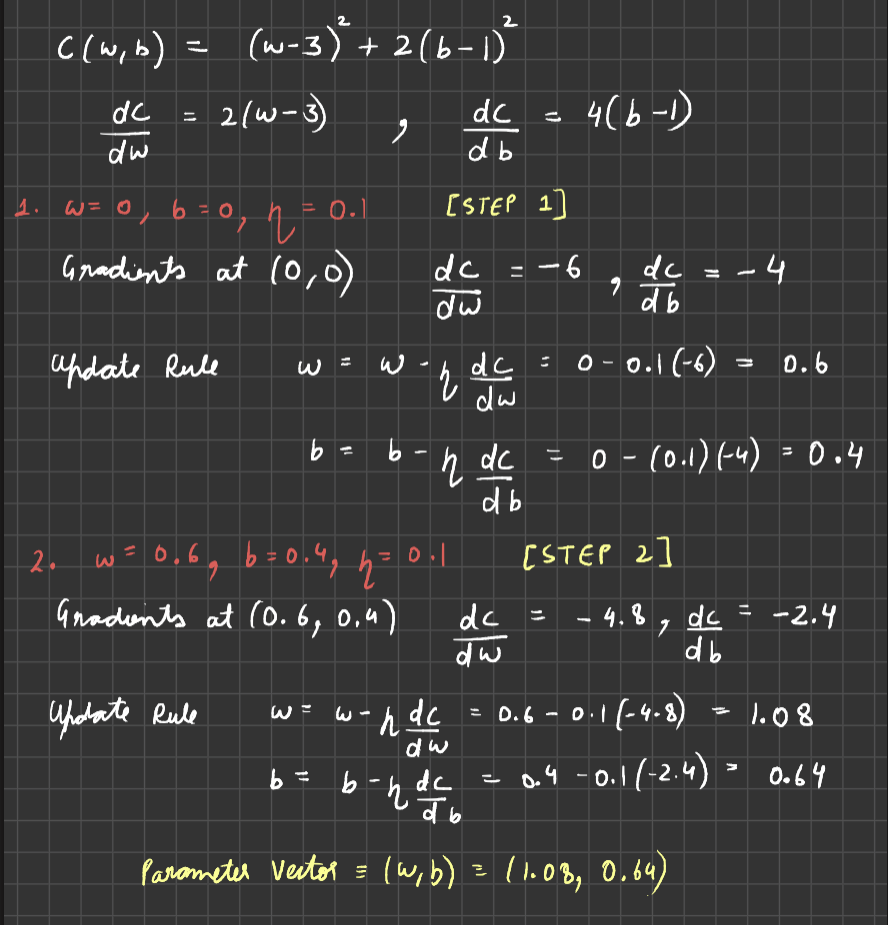

In [13]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2 * (w - 3)
    db = 4 * (b - 1)
    return dw, db

# Verify hand calculation
eta = 0.1
w, b = 0.0, 0.0

for step in range(1, 3):
    dw, db = grad_cost(w, b)

    w = w - eta * dw
    b = b - eta * db

    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**
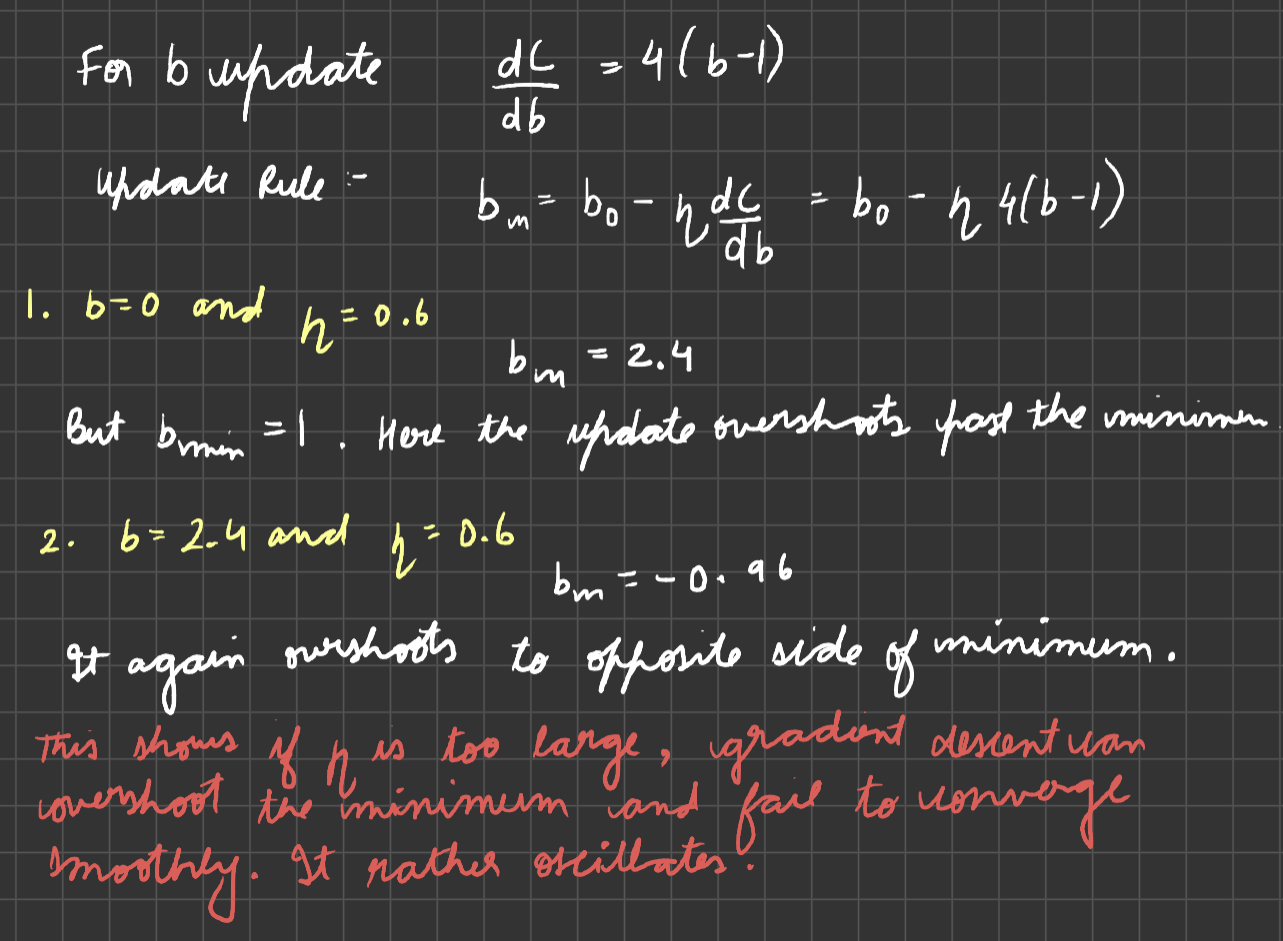

In [14]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [6]:

class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, x):
        # compute z = w.x + b
        z = np.dot(self.weights, x) + self.bias

        # return sigmoid(z)
        return self.sigmoid(z)

    def numerical_gradient(self, x, h=1e-5):

        grad_weights = np.zeros_like(self.weights)

        # gradients for weights
        for i in range(len(self.weights)):

            original = self.weights[i]

            self.weights[i] = original + h
            f_plus = self.forward(x)

            self.weights[i] = original - h
            f_minus = self.forward(x)

            grad_weights[i] = (f_plus - f_minus) / (2 * h)

            # restore original value
            self.weights[i] = original

        # gradient for bias
        original_bias = self.bias

        self.bias = original_bias + h
        f_plus = self.forward(x)

        self.bias = original_bias - h
        f_minus = self.forward(x)

        grad_bias = (f_plus - f_minus) / (2 * h)

        # restore original bias
        self.bias = original_bias

        return grad_weights, grad_bias

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [8]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:**
The gradient w.r.t. w1 tells us how sensitive the neuron’s output is to small changes in the first weight. Here, d(output)/dw1=0.149146 means that if w1 increases slightly, the output will also increase by about 0.149 times that change.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**
1. At z=0, the gradient is largest.
2. As z approaches +/- infinity, the sigmoid output becomes very close to 1 or 0 and the derivative approaches 0. This causes the vanishing gradient problem. The gradients become tiny, making weight updates during backpropagation extremely small and slowing learning.

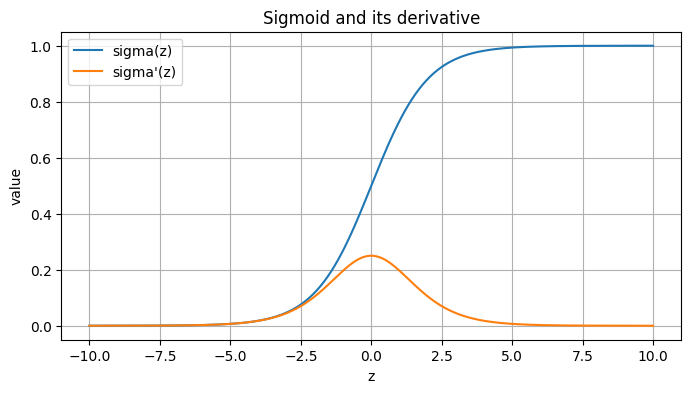

In [10]:

z = np.linspace(-10, 10, 500)

# sigmoid
sigma = 1 / (1 + np.exp(-z))

# derivative
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))

plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_prime, label="sigma'(z)")

plt.xlabel('z')
plt.ylabel('value')
plt.legend()

plt.title('Sigmoid and its derivative')

plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**
The claim is mostly correct because multiplying the weights by 100 makes the sigmoid extremely steep, so it behaves almost like a step function. However near z=0, sigmoid is still smooth and continuous while the perceptron changes abruptly. Also, sigmoid outputs are never exactly 0 or 1, unlike a true perceptron.

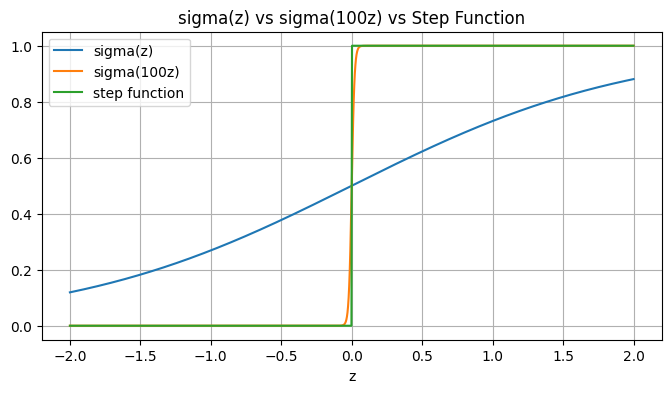

In [11]:
z = np.linspace(-2, 2, 1000)

# sigmoid
sigma = 1 / (1 + np.exp(-z))

# steep sigmoid
sigma_100 = 1 / (1 + np.exp(-100 * z))

# step function
step = (z >= 0).astype(int)

plt.figure(figsize=(8, 4))

plt.plot(z, sigma, label='sigma(z)')
plt.plot(z, sigma_100, label='sigma(100z)')
plt.plot(z, step, label='step function')

plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')

plt.legend()
plt.grid(True)

plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [20]:
x_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra)-**

> **Your answer:**
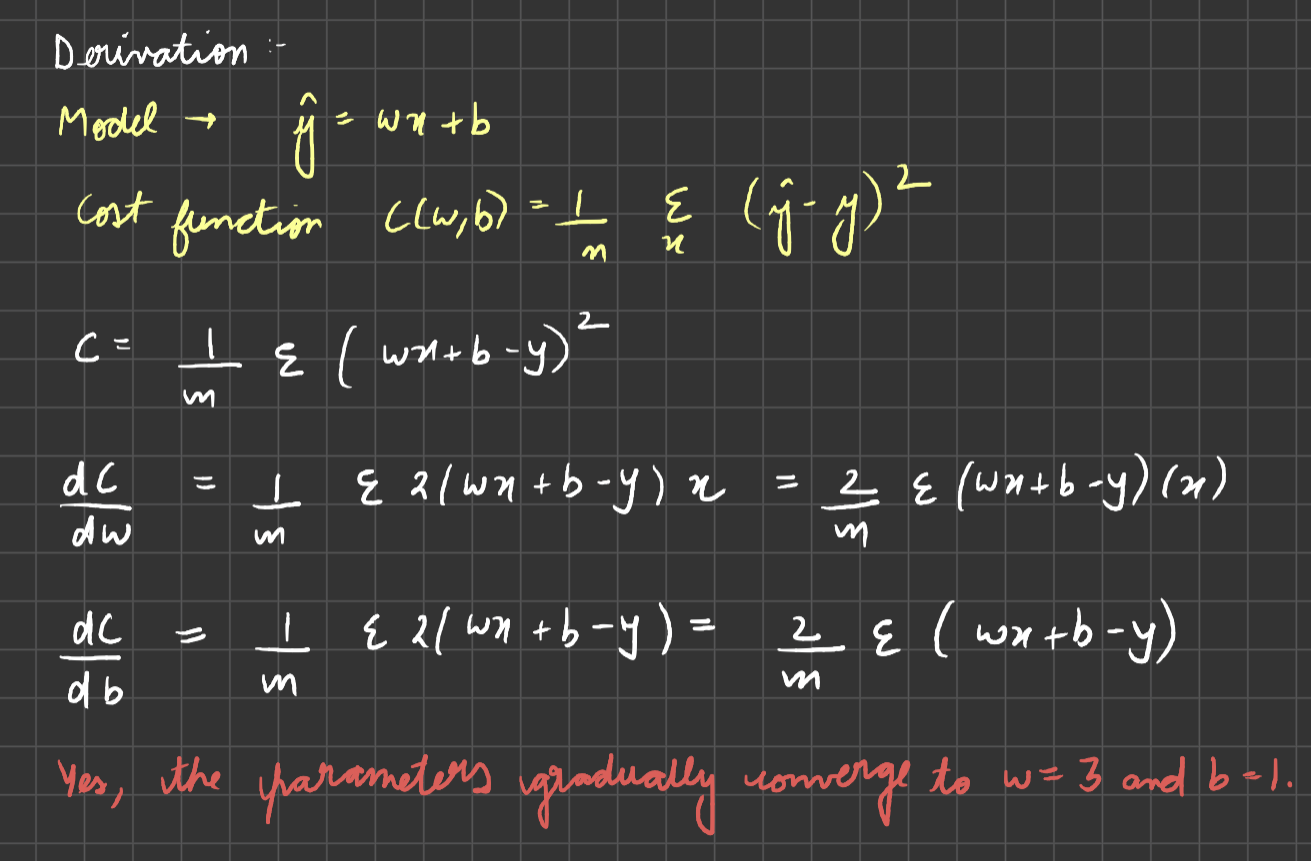

Final w = 2.9951, b = 1.0141


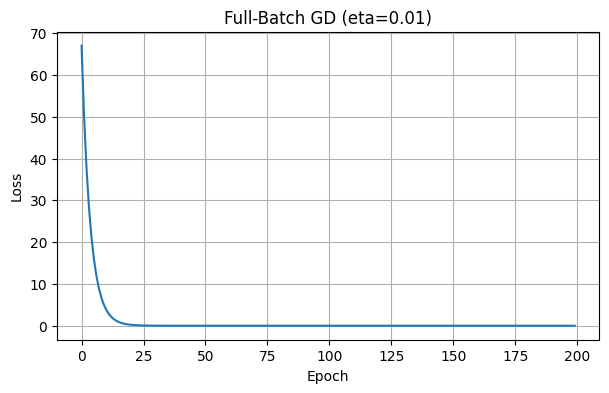

In [22]:
w, b = 0.0, 0.0
eta = 0.01

losses = []

n = len(x_train)

for epoch in range(200):

    # predictions
    y_pred = w * x_train + b

    # loss
    loss = np.mean((y_pred - y_train)**2)

    losses.append(loss)

    # gradients
    dw = (2/n) * np.sum((y_pred - y_train) * x_train)
    db = (2/n) * np.sum(y_pred - y_train)

    # parameter update
    w = w - eta * dw
    b = b - eta * db

print(f'Final w = {w:.4f}, b = {b:.4f}')

plt.figure(figsize=(7, 4))

plt.plot(losses)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Full-Batch GD (eta=0.01)')

plt.grid(True)

plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**
The SGD loss curve is usually noisier and less smooth than full-batch gradient descent. This happens because each update uses only one training example, so the gradient estimate is noisy and may not point exactly toward the true minimum. Full-batch GD uses the entire dataset, giving a more accurate and stable gradient, so its loss curve is smoother.

Final w = 2.9921, b = 1.0220


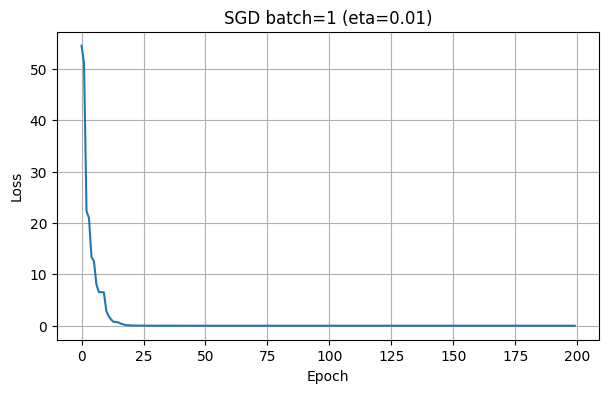

In [24]:
w, b = 0.0, 0.0
eta = 0.01

losses_sgd = []

for epoch in range(200):

    # pick one random training example
    idx = np.random.randint(0, len(x_train))

    x = x_train[idx]
    y = y_train[idx]

    # prediction
    y_pred = w * x + b

    # gradients
    dw = 2 * (y_pred - y) * x
    db = 2 * (y_pred - y)

    # update
    w = w - eta * dw
    b = b - eta * db

    # compute full dataset loss for plotting
    full_pred = w * x_train + b

    loss = np.mean((full_pred - y_train)**2)

    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')

plt.figure(figsize=(7, 4))

plt.plot(losses_sgd)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('SGD batch=1 (eta=0.01)')

plt.grid(True)

plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**
Using the gradient formula in 5a, the updates become very large when the learning rate  (eta) is set to 0.5. Since the gradients are multiplied directly by eta, the parameter updates overshoot the minimum instead of moving smoothly towards it.

Final w = -188122612283167724182955396233061990400.0000, b = -65989849225923788023301178152309489664.0000


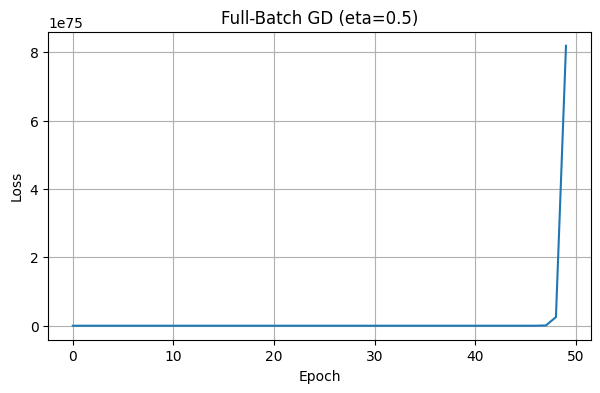

In [25]:
w, b = 0.0, 0.0
eta = 0.5

losses = []

n = len(x_train)

for epoch in range(50):

    # predictions
    y_pred = w * x_train + b

    # loss
    loss = np.mean((y_pred - y_train)**2)

    losses.append(loss)

    # gradients
    dw = (2/n) * np.sum((y_pred - y_train) * x_train)
    db = (2/n) * np.sum(y_pred - y_train)

    # update
    w = w - eta * dw
    b = b - eta * db

print(f'Final w = {w:.4f}, b = {b:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5)')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning-**

> **Your answer:**
The 10 outputs are one-hot encoded, so only one neuron is 1 at a time. The 4-neuron layer is made so that each neuron represents one binary bit. The weight matrix stores the binary form of each digit in its columns. When a one-hot input is multiplied with the matrix, it directly gives the correct 4-bit binary output. No bias is needed because the weights already produce the required values.

In [7]:
W = np.array([
    # MSB
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],

    # second bit
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],

    # third bit
    [0, 0, 1, 1, 0, 0, 1, 1, 0, 0],

    # LSB
    [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
], dtype=float)

# no bias needed
b_enc = np.zeros(4)

def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)

for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0

    out = threshold(W @ one_hot + b_enc)

    expected = format(digit, '04b')

    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'

    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**
1. The derivative gives the slope of the cost function w.r.t. the parameter. The update rule moves the parameter opposite to the sign of slope to reduce the overall cost.
2. The slope determines the direction of movement in which +ve slope means to go left, -ve slope means to go right. The slope along with the learning rate helps to determine how large each movement should be.

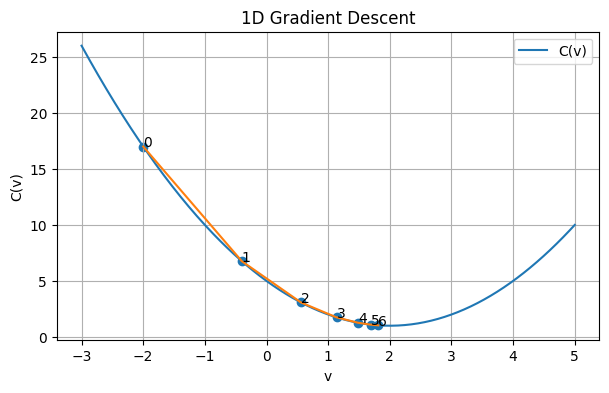

In [8]:
# Cost function
def cost(v):
    return (v - 2)**2 + 1

# Derivative dC/dv
def grad(v):
    return 2 * (v - 2)

# Curve points
v_vals = np.linspace(-3, 5, 300)
C_v = cost(v_vals)

# Initial value
v = -2
alpha = 0.2

# Store steps
v_history = [v]
c_history = [cost(v)]

# Run gradient descent
for _ in range(6):

    dv = grad(v)

    v = v - alpha * dv

    v_history.append(v)
    c_history.append(cost(v))

# Plot curve
plt.figure(figsize=(7, 4))

plt.plot(v_vals, C_v, label='C(v)')

# Plot gradient descent steps
plt.scatter(v_history, c_history)

# Connect steps
plt.plot(v_history, c_history)

# Label points
for i in range(len(v_history)):
    plt.text(v_history[i], c_history[i], f'{i}')

plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)

plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**
1. By removing all hidden layers and connecting 784 inputs directly to 10 outputs, we effectively create a multiclass linear classifier.
2. Classification accuracy is fundamentally capped because the model can only learn linear decision boundaries. Real image data like handwritten digits is highly nonlinear, so many patterns cannot be separated perfectly using only straight hyperplanes.
3. This implies hidden layers are necessary because they allow the network to learn hierarchical and nonlinear features, enabling complex decision boundaries and much higher accuracy.